# Day 2 – Olympic Dataset Exploration

This notebook explores the Olympic athletes dataset used for the medal prediction project.

Goals:
- Understand dataset structure
- Identify missing values
- Explore medal distribution
- Explore sport and country participation

## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/olympics_athletes_dataset.csv")

df.head()

Matplotlib is building the font cache; this may take a moment.


,athlete_id,athlete_name,gender,age,date_of_birth,nationality,country_name,sport,event,games_type,...,bronze_medals,country_total_gold,country_total_medals,country_first_participation,country_best_rank,is_record_holder,coach_name,height_cm,weight_kg,notes
0,ATH-00001,Svetlana Jung,Female,19,2005-12-04,AUT,Austria,Rowing,Four W,Summer,...,1,59,196,1896,18,No,Wei Ping,175.9,73.7,-
1,ATH-00002,Mary Yamamoto,Female,37,1987-07-11,MEX,Mexico,Ski Jumping,Normal Hill Team,Winter,...,5,14,72,1924,35,No,Yury Zakharevich,165.4,68.3,Olympic Debut
2,ATH-00003,Oksana Volkov,Female,37,1987-02-02,BUL,Bulgaria,Figure Skating,Women's Singles,Winter,...,1,54,224,1896,15,No,Alberto Salazar,164.2,67.2,-
3,ATH-00004,Rui Suzuki,Male,32,1992-12-08,HKG,Hong Kong,Triathlon,Men's Triathlon,Summer,...,0,3,9,1952,60,Olympic Record,Marcus O'Sullivan,190.0,76.0,First from country
4,ATH-00005,Natalya Grigoryan,Female,27,1997-11-15,SWE,Sweden,Triathlon,Men's Triathlon,Summer,...,0,200,648,1896,4,No,John Smith,175.8,60.9,Season Best


## Dataset Overview

In [2]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   athlete_id                   8500 non-null   str    
 1   athlete_name                 8500 non-null   str    
 2   gender                       8500 non-null   str    
 3   age                          8500 non-null   int64  
 4   date_of_birth                8500 non-null   str    
 5   nationality                  8500 non-null   str    
 6   country_name                 8500 non-null   str    
 7   sport                        8500 non-null   str    
 8   event                        8500 non-null   str    
 9   games_type                   8500 non-null   str    
 10  year                         8500 non-null   int64  
 11  host_city                    8500 non-null   str    
 12  team_or_individual           8500 non-null   str    
 13  medal                        

In [3]:
df.describe()

,age,year,result_value,total_olympics_attended,total_medals_won,gold_medals,silver_medals,bronze_medals,country_total_gold,country_total_medals,country_first_participation,country_best_rank,height_cm,weight_kg
count,8500.000000,8500.000000,8500.000000,8500.00000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000
mean,28.531176,1967.250824,747.450624,2.98800,4.133647,2.037647,1.028941,1.067059,115.538353,341.887882,1919.541412,19.995529,178.873812,77.158753
std,8.074316,45.062096,1906.176179,1.42072,2.562461,2.042781,1.419565,1.459811,176.862799,456.193805,30.748547,17.602927,11.375077,16.528412
min,15.000000,1896.000000,0.011000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1896.000000,1.000000,145.000000,40.100000
25%,22.000000,1920.000000,10.359250,2.00000,2.000000,0.000000,0.000000,0.000000,19.000000,60.000000,1896.000000,4.000000,170.300000,65.100000
50%,28.000000,1984.000000,129.507500,3.00000,4.000000,1.000000,1.000000,1.000000,54.000000,196.000000,1900.000000,15.000000,178.700000,75.300000
75%,36.000000,2008.000000,345.382750,4.00000,6.000000,3.000000,1.000000,2.000000,170.000000,497.000000,1948.000000,33.000000,187.300000,87.300000
max,42.000000,2024.000000,14979.675000,5.00000,9.000000,8.000000,8.000000,8.000000,1061.000000,2638.000000,2008.000000,62.000000,215.000000,149.700000


## Check for missing values

In [4]:
df.isnull().sum().sort_values(ascending=False).head(15)

athlete_id                     0
athlete_name                   0
weight_kg                      0
height_cm                      0
coach_name                     0
is_record_holder               0
country_best_rank              0
country_first_participation    0
country_total_medals           0
country_total_gold             0
bronze_medals                  0
silver_medals                  0
gold_medals                    0
total_medals_won               0
total_olympics_attended        0
dtype: int64

Observations:
- Some athletes missing height/weight
- Medal column mostly "No Medal"

## Medal Distribution

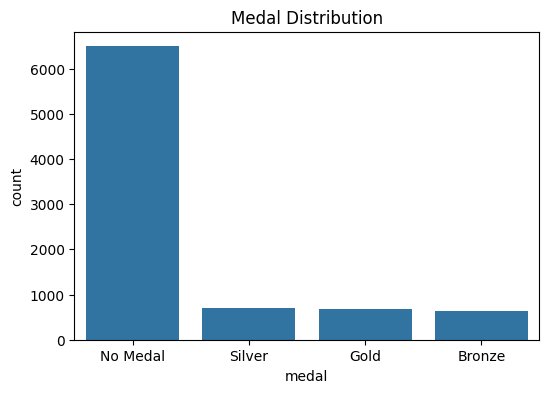

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="medal",
              order=df["medal"].value_counts().index)

plt.title("Medal Distribution")
plt.show()

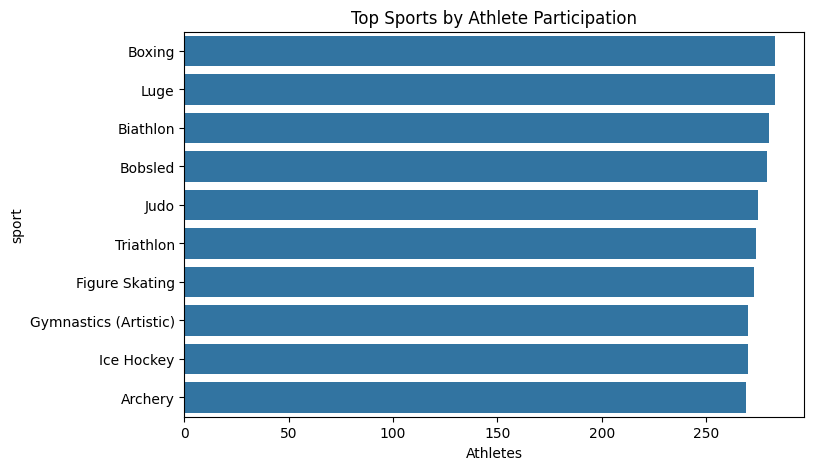

In [7]:
top_sports = df["sport"].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_sports.values, y=top_sports.index)

plt.title("Top Sports by Athlete Participation")
plt.xlabel("Athletes")
plt.show()

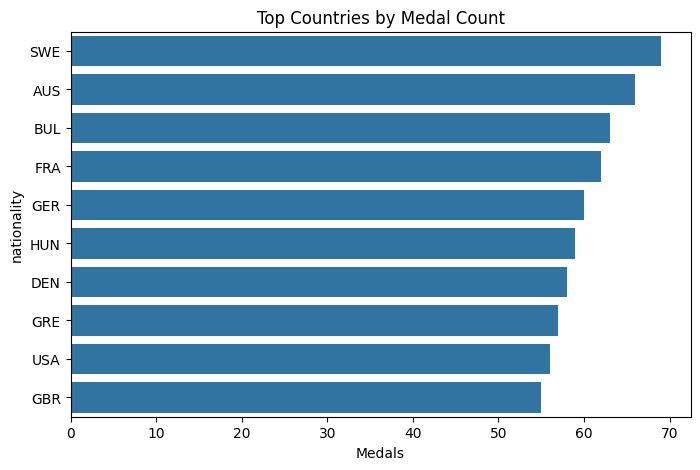

In [8]:
medal_df = df[df["medal"] != "No Medal"]

top_countries = medal_df["nationality"].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries by Medal Count")
plt.xlabel("Medals")
plt.show()

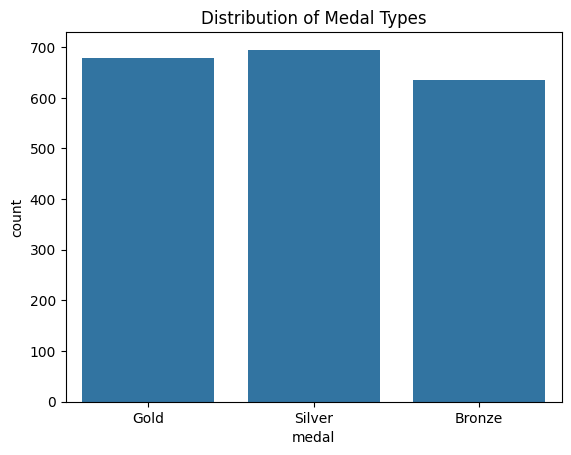

In [9]:
medal_df = df[df["medal"] != "No Medal"]

sns.countplot(data=medal_df, x="medal",
              order=["Gold","Silver","Bronze"])
plt.title("Distribution of Medal Types")
plt.show()

## Key Insights

1. Medal outcomes are highly imbalanced  
The majority of athlete entries result in "No Medal", while gold, silver, and bronze medals represent a small fraction of observations.  
This indicates that medal prediction will be an imbalanced classification problem, which may require techniques such as class weighting or resampling.

2. Athlete participation is concentrated in a small set of sports  
A limited number of sports account for the highest number of athlete entries (e.g., Boxing, Luge, Biathlon).  
This suggests that sport-specific patterns may influence medal outcomes and should be considered as features during modeling.

3. Medal counts are dominated by a subset of countries  
A small group of countries contributes a large portion of medal-winning athletes.  
Country-level historical performance may therefore be an important predictor when estimating medal probability.

4. The dataset contains both athlete-level and country-level information  
Variables such as age, sport, nationality, and historical country medal counts provide multiple levels of information that could help predict medal outcomes.